578458733.286251


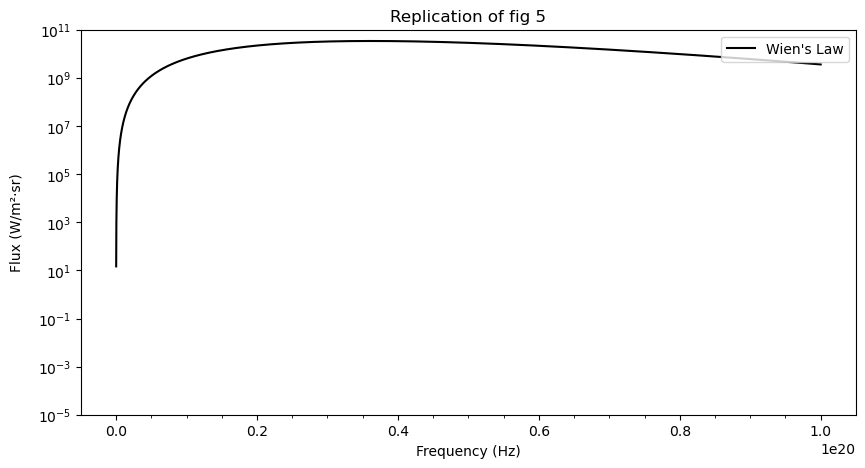

In [2]:
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.constants import h, c, k_B, m_p, R_sun, au
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Parameters that you can change for new model
c_factor = 0.6 #factor to change the speed of light for the velocity of forward shock
v_fs = c_factor * c.cgs.value #velocity of forward shock in m/s
dens = 1e-16 #density of agn disk

# Constants used 
#t = 5800 #Temp of sun for now can change for what we are looking at 
rad = R_sun #Radius of sun in meters for now will change to bh later
d = au #distance from earth to sun in meters change later to distance to agn
h = h.cgs.value #Planck constant
c = c.cgs.value #speed of light
k = k_B.cgs.value #Boltzmann constant
m_p = m_p.cgs.value #proton mass
pi = np.pi #Pi constant
freq_list = np.logspace(16, 20, 10000) #frequency range for graph in Hz

# Function to calculate temperature based on velocity of forward shock and density
def temp_fxn(v_fs, dens, m_p, c, k):
    """
    Calculate the temperature t based on velocity of forward shock and other physical parameters. All parameters should be in CGS units

    Parameters
    ----------
    v_fs : float
        Velocity of the forward shock in m/s.
    dens : float
        Density of AGN disk.
    m_p : float
        Proton mass.
    c : float
        Speed of light.
    k : float
        Boltzmann constant.

    Returns
    -------
    t : float
        Calculated temperature.
    """
    b_fs = v_fs / c
    gamma_fs = 1 / np.sqrt(1 - b_fs**2)
    gamma_fs_f = gamma_fs**(1 + np.sqrt(3))
    gamma_sf = gamma_fs / np.sqrt(2)
    gamma_sf_f = gamma_sf**(1 + np.sqrt(3))
    n = dens / m_p

    if b_fs * gamma_fs <= 0.03:
        t = 1e4 * ((b_fs / 0.02)**0.5) * ((dens / 1e-16)**0.25)
    elif b_fs * gamma_fs > 0.03 and b_fs * gamma_fs <= 1:
        t = (10**(0.975 + (1.735 * ((b_fs / 0.1)**0.5)) + ((0.26 - 0.08 * ((b_fs / 0.1)**0.5)) * np.log10(n / 1e15)))) * 1e4
    elif b_fs * gamma_fs > 1:
        t = (gamma_sf_f * 5e4) / k
    if b_fs >= 1:
        print("Velocity is greater than speed of light, using beta = 0.98 instead")
        b_fs = 0.98
        gamma_fs = 1 / np.sqrt(1 - b_fs**2)
        gamma_sf = gamma_fs / np.sqrt(2)
        gamma_sf_f = gamma_sf**(1 + np.sqrt(3))
        t = (gamma_sf_f * 5e4) / k
    return t

# Plancks law for frequency in graph
def planck_fxn(filter, t):
    """Planck's law for frequency
    This function calculates the spectral radiance of a black body at a given temperature T for a specific frequency filter. All parameters should be in CGS units
    
    
    Parameters
    ----------
    filter : array-like 
        The frequency values for which to calculate the spectral radiance.
    t : float
        The temperature of the black body in Kelvin. Taken from the if functions depending on velocity of forward shock.
    Returns
    -------
    B : array-like
        Spectral radiance of the black body at the given frequency and temperature."""
    B = (((2*h*(filter**3))/(c**2)))*((1/(np.exp((h*filter)/(k*t))-1)))
    return B

#for when b is greater than 0.03 but less than 1 use wien in graph
def wien_fxn(filter, t):

    """Wien's law for frequency
    This function calculates the spectral radiance of a black body at a given temperature T for a specific frequency filter. All parameters should be in CGS units
    
    
    Parameters
    ----------
    filter : array-like
        The frequency values for which to calculate the spectral radiance.
    t : float
        The temperature of the black body in Kelvin. Taken from the if functions depending on velocity of forward shock.
    Returns
    -------
    B : array-like
        Spectral radiance of the black body at the given frequency and temperature."""
    B = ((2 * h * (filter**3)) / (c**2)) * np.exp(-((h * filter)/(k * t)))
    return B


b_fs = v_fs / c
gamma_fs = 1 / np.sqrt(1 - b_fs**2)

t = temp_fxn(v_fs, dens, m_p, c, k)  # Calculate temperature based on forward shock velocity and density

# Planck's law for frequency (for when b_fs * gamma_fs <= 0.03)
planck_total = planck_fxn(freq_list, t) #planck law for the whole frequency range for graph
 

# planck law based on area
planck_area = (planck_total * pi * (rad**2))

# planck law based on distance 
planck_dist = (planck_area/(4 * pi * (d**2)))

#t_mid = 1e4

# Wien's law for frequency (used when b_fs * gamma_fs > 0.03)
wien_total = wien_fxn(freq_list, t) #wien law for the whole frequency range for graph


# when b  is greater than 1 force it to use beta = 1- precision of instruement and give a warning 

print(t)

# Plot Code
plt.figure(figsize=(10, 5))

if b_fs*gamma_fs <= 0.03:
    plt.plot(freq_list, planck_total, color='black', label="Planck's Law")
    plt.yscale('log')  # Set y-axis to logarithmic scale
else:
    plt.plot(freq_list, wien_total, color='black', label="Wien's Law")
    plt.yscale('log')  # Set y-axis to logarithmic scale

#labels
plt.xlabel("Frequency (Hz)")
plt.ylabel("Flux (W/m²·sr)", labelpad=10)
plt.ylim(bottom=1e-5) # Makes y axis at 0
plt.minorticks_on()  # Add ticks inside the axis
plt.title("Replication of fig 5")
plt.legend(loc='upper right')

plt.show()
